In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [215]:
x, y = load_diabetes(return_X_y=True)
print(x.shape)
print(y.shape)

(442, 10)
(442,)


In [216]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [217]:
print(x_train.shape)

(353, 10)


In [218]:
reg = LinearRegression()
reg.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ -9.16,-205.45, 516.69,..., 126.73, 861.13, 52.42]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,151.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[1.79,1.1 ,0.98,...,0.58,0.24,0.08]"


In [219]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [220]:
y_pred = reg.predict(x_test)
r2_score(y_test, y_pred)

0.439933866156897

In [ ]:
class GDR:
    def __init__(self, lr=0.1, epochs=100):
        self.intercept = None  # Intercept = b
        self.coef = None  # coefficient = fn(w)
        self.lr = lr
        self.epochs = epochs
        self.losses = []

    def model(self, x_train, y_train):
        self.intercept = 0
        self.coef = np.ones(x_train.shape[1])

        for i in range(self.epochs):
            y_pred = np.dot(x_train, self.coef) + self.intercept
            err = np.mean(np.square(y_train - y_pred))
            self.losses.append(err)

            # Finding the slope of intercept and coef
            intercept_dev = -2 * np.mean(y_train - y_pred)
            coef_dev = -2 * np.dot((y_train - y_pred), x_train) / x_train.shape[0]

            # Updating the intercept and coef
            self.intercept -= self.lr * intercept_dev
            self.coef -= self.lr * coef_dev

        plt.figure()
        plt.plot(self.losses, color="green")
        plt.title("Linear Regression - Loss (MSE)")
        plt.xlabel("Epochs")
        plt.ylabel("Loss (MSE)")
        plt.grid(True)

        plt.show()

    def predict(self, x_test):
        return np.dot(x_test, self.coef) + self.intercept

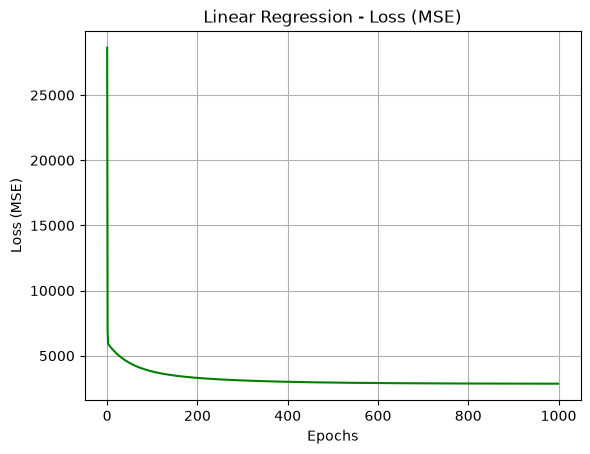

In [222]:
gdr = GDR(0.6, 1000)
gdr.model(x_train, y_train)

In [223]:
pred = gdr.predict(x_test)
r2_score(y_test, pred)

0.4520736256827782